In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jockeroika/life-style-data")

print("Path to dataset files:", path) 

c:\Users\Karolcia\anaconda3\envs\AI_2025\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.81M/3.81M [00:00<00:00, 4.27MB/s]

Extracting files...


Path to dataset files: C:\Users\Karolcia\.cache\kagglehub\datasets\jockeroika\life-style-data\versions\7


In [ ]:
import pandas as pd
import numpy as np
import pyspark as psp
import os
import ast
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = os.path.join(path,'Final_data.csv')
df = pd.read_csv(dataset_path)
df_all = pd.DataFrame(df)

In [ ]:
print("Udzial procentowy nulli:")
(df_all.isna().sum().sum()/len(df_all))*100

Udzial procentowy nulli:


np.float64(0.0)

In [26]:
df_all.head(5)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [27]:
integer_columns = df_all.select_dtypes(include=['int64']).columns
float_columns = df_all.select_dtypes(include=['float64']).columns
object_columns = df_all.select_dtypes(include=['object']).columns

print('\nint64 columns:\n', integer_columns)
print('\nfloat64 columns:\n', float_columns)
print('\nobject columns:\n', object_columns)



int64 columns:
 Index([], dtype='object')

float64 columns:
 Index(['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake (liters)', 'Workout_Frequency (days/week)',
       'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise',
       'Carbs', 'Proteins', 'Fats', 'Calories', 'sugar_g', 'sodium_mg',
       'cholesterol_mg', 'serving_size_g', 'prep_time_min', 'cook_time_min',
       'rating', 'Sets', 'Reps', 'Burns Calories (per 30 min)', 'BMI_calc',
       'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR',
       'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc'],
      dtype='object')

object columns:
 Index(['Gender', 'Workout_Type', 'meal_name', 'meal_type', 'diet_type',
       'cooking_method', 'Name of Exercise', 'Benefit', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 

In [28]:
df_all[object_columns].head(20)

,Gender,Workout_Type,meal_name,meal_type,diet_type,cooking_method,Name of Exercise,Benefit,Target Muscle Group,Equipment Needed,Difficulty Level,Body Part,Type of Muscle,Workout,Burns_Calories_Bin
0,Male,Strength,Other,Lunch,Vegan,Grilled,Decline Push-ups,Improves shoulder health and posture,"Shoulders, Triceps",Cable Machine,Advanced,Legs,Lats,Dumbbell flyes,Medium
1,Female,HIIT,Other,Lunch,Vegetarian,Fried,Bear Crawls,Strengthens lower abs,"Back, Core, Shoulders",Step or Box,Intermediate,Chest,Lats,Lateral raises,High
2,Female,Cardio,Other,Breakfast,Paleo,Boiled,Dips,Builds chest strength,"Quadriceps, Glutes",Step or Box,Intermediate,Arms,Grip Strength,Standing calf raises,High
3,Female,HIIT,Other,Lunch,Paleo,Fried,Mountain Climbers,Improves coordination and cardiovascular health,"Biceps, Forearms",Parallel Bars or Chair,Advanced,Shoulders,Upper,Incline dumbbell flyes,High
4,Male,Strength,Other,Breakfast,Vegan,Baked,Bicep Curls,Targets obliques and improves core rotation,"Chest, Triceps",Wall,Advanced,Abs,Wrist Flexors,Military press,Low
5,Female,Yoga,Other,Snack,Keto,Steamed,Leg Press,Builds explosive power,"Core, Obliques",Resistance Band or Cable Machine,Beginner,Arms,Wrist Flexors,Skull crushers,Very High
6,Male,Strength,Other,Breakfast,Low-Carb,Fried,Thrusters,Strengthens back and improves posture,Core,None or Dumbbells,Advanced,Shoulders,Wrist Flexors,Barbell rows,Low
7,Female,Yoga,Other,Snack,Low-Carb,Raw,Turkish Get-ups,Improves core stability and upper body strength,"Back, Biceps",Pull-up Bar,Intermediate,Back,Lower,Hammer curl,Very High
8,Female,Strength,Other,Lunch,Vegan,Boiled,Glute Bridges,Full body workout,"Upper Chest, Triceps",Barbell,Beginner,Chest,Middle,Russian twists,High
9,Female,Strength,Other,Lunch,Paleo,Grilled,Step-ups,Builds chest strength,"Core, Lower Back",Low Bar or TRX,Intermediate,Forearms,Lower Chest,Towel pull-up,Low


In [ ]:
df_all = df_all['Gender', 'Age', 'Weight (kg)', 'Height (m)', 'Avg_BPM' ,'Resting_BPM', '', '', '', '' ,'', '', '', '', '', '', '' ,'', '', '', '' ,'', '' ,'' ,'' ,'', '', '', '', '', '']

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label1 = le.fit_transform(df_all['Gender'])
df_all["Gender2"] = label1

label2 = le.fit_transform(df_all['Workout_Type'])
df_all["Workout_Type2"] = label2

label3 = le.fit_transform(df_all['meal_type'])
df_all["meal_type2"] = label3

label4 = le.fit_transform(df_all['diet_type'])
df_all["diet_type2"] = label4

label5 = le.fit_transform(df_all['Name of Exercise'])
df_all["Name of Exercise2"] = label5

label6 = le.fit_transform(df_all['cooking_method'])
df_all["cooking_method2"] = label6

label7 = le.fit_transform(df_all['Body Part'])
df_all["Body Part2"] = label7

label8 = le.fit_transform(df_all['Burns_Calories_Bin'])
df_all["Burns_Calories_Bin2"] = label8

In [31]:
df_all.head(20)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,Gender2,Workout_Type2,meal_type2,diet_type2,Name of Exercise2,cooking_method2,Body Part2,Burns_Calories_Bin2
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,7.260425e+19,Medium,1,2,2,4,12,3,5,2
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1.020506e+20,High,0,1,2,5,0,2,3,0
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1.079607e+20,High,0,0,0,3,13,1,1,0
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,8.987921e+19,High,0,1,2,3,28,2,6,0
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,5.264685e+19,Low,1,2,0,4,2,0,0,1
5,53.19,Female,105.05,1.84,176.52,130.60,61.84,0.69,453.33,Yoga,...,1.505159e+20,Very High,0,3,3,1,25,6,1,3
6,23.17,Male,58.41,1.78,184.75,140.90,58.01,1.67,1953.90,Strength,...,5.210106e+19,Low,1,2,0,2,48,2,6,1
7,55.92,Female,84.07,1.63,183.87,141.12,51.79,1.01,727.81,Yoga,...,1.179846e+20,Very High,0,3,3,2,51,4,2,3
8,24.11,Female,88.58,1.79,176.78,154.07,65.19,1.76,2062.37,Strength,...,8.550761e+19,High,0,2,2,4,18,1,3,0
9,39.19,Female,50.32,1.60,166.88,128.04,49.91,1.17,1157.25,Strength,...,4.879494e+19,Low,0,2,2,3,46,3,4,1


<Axes: >

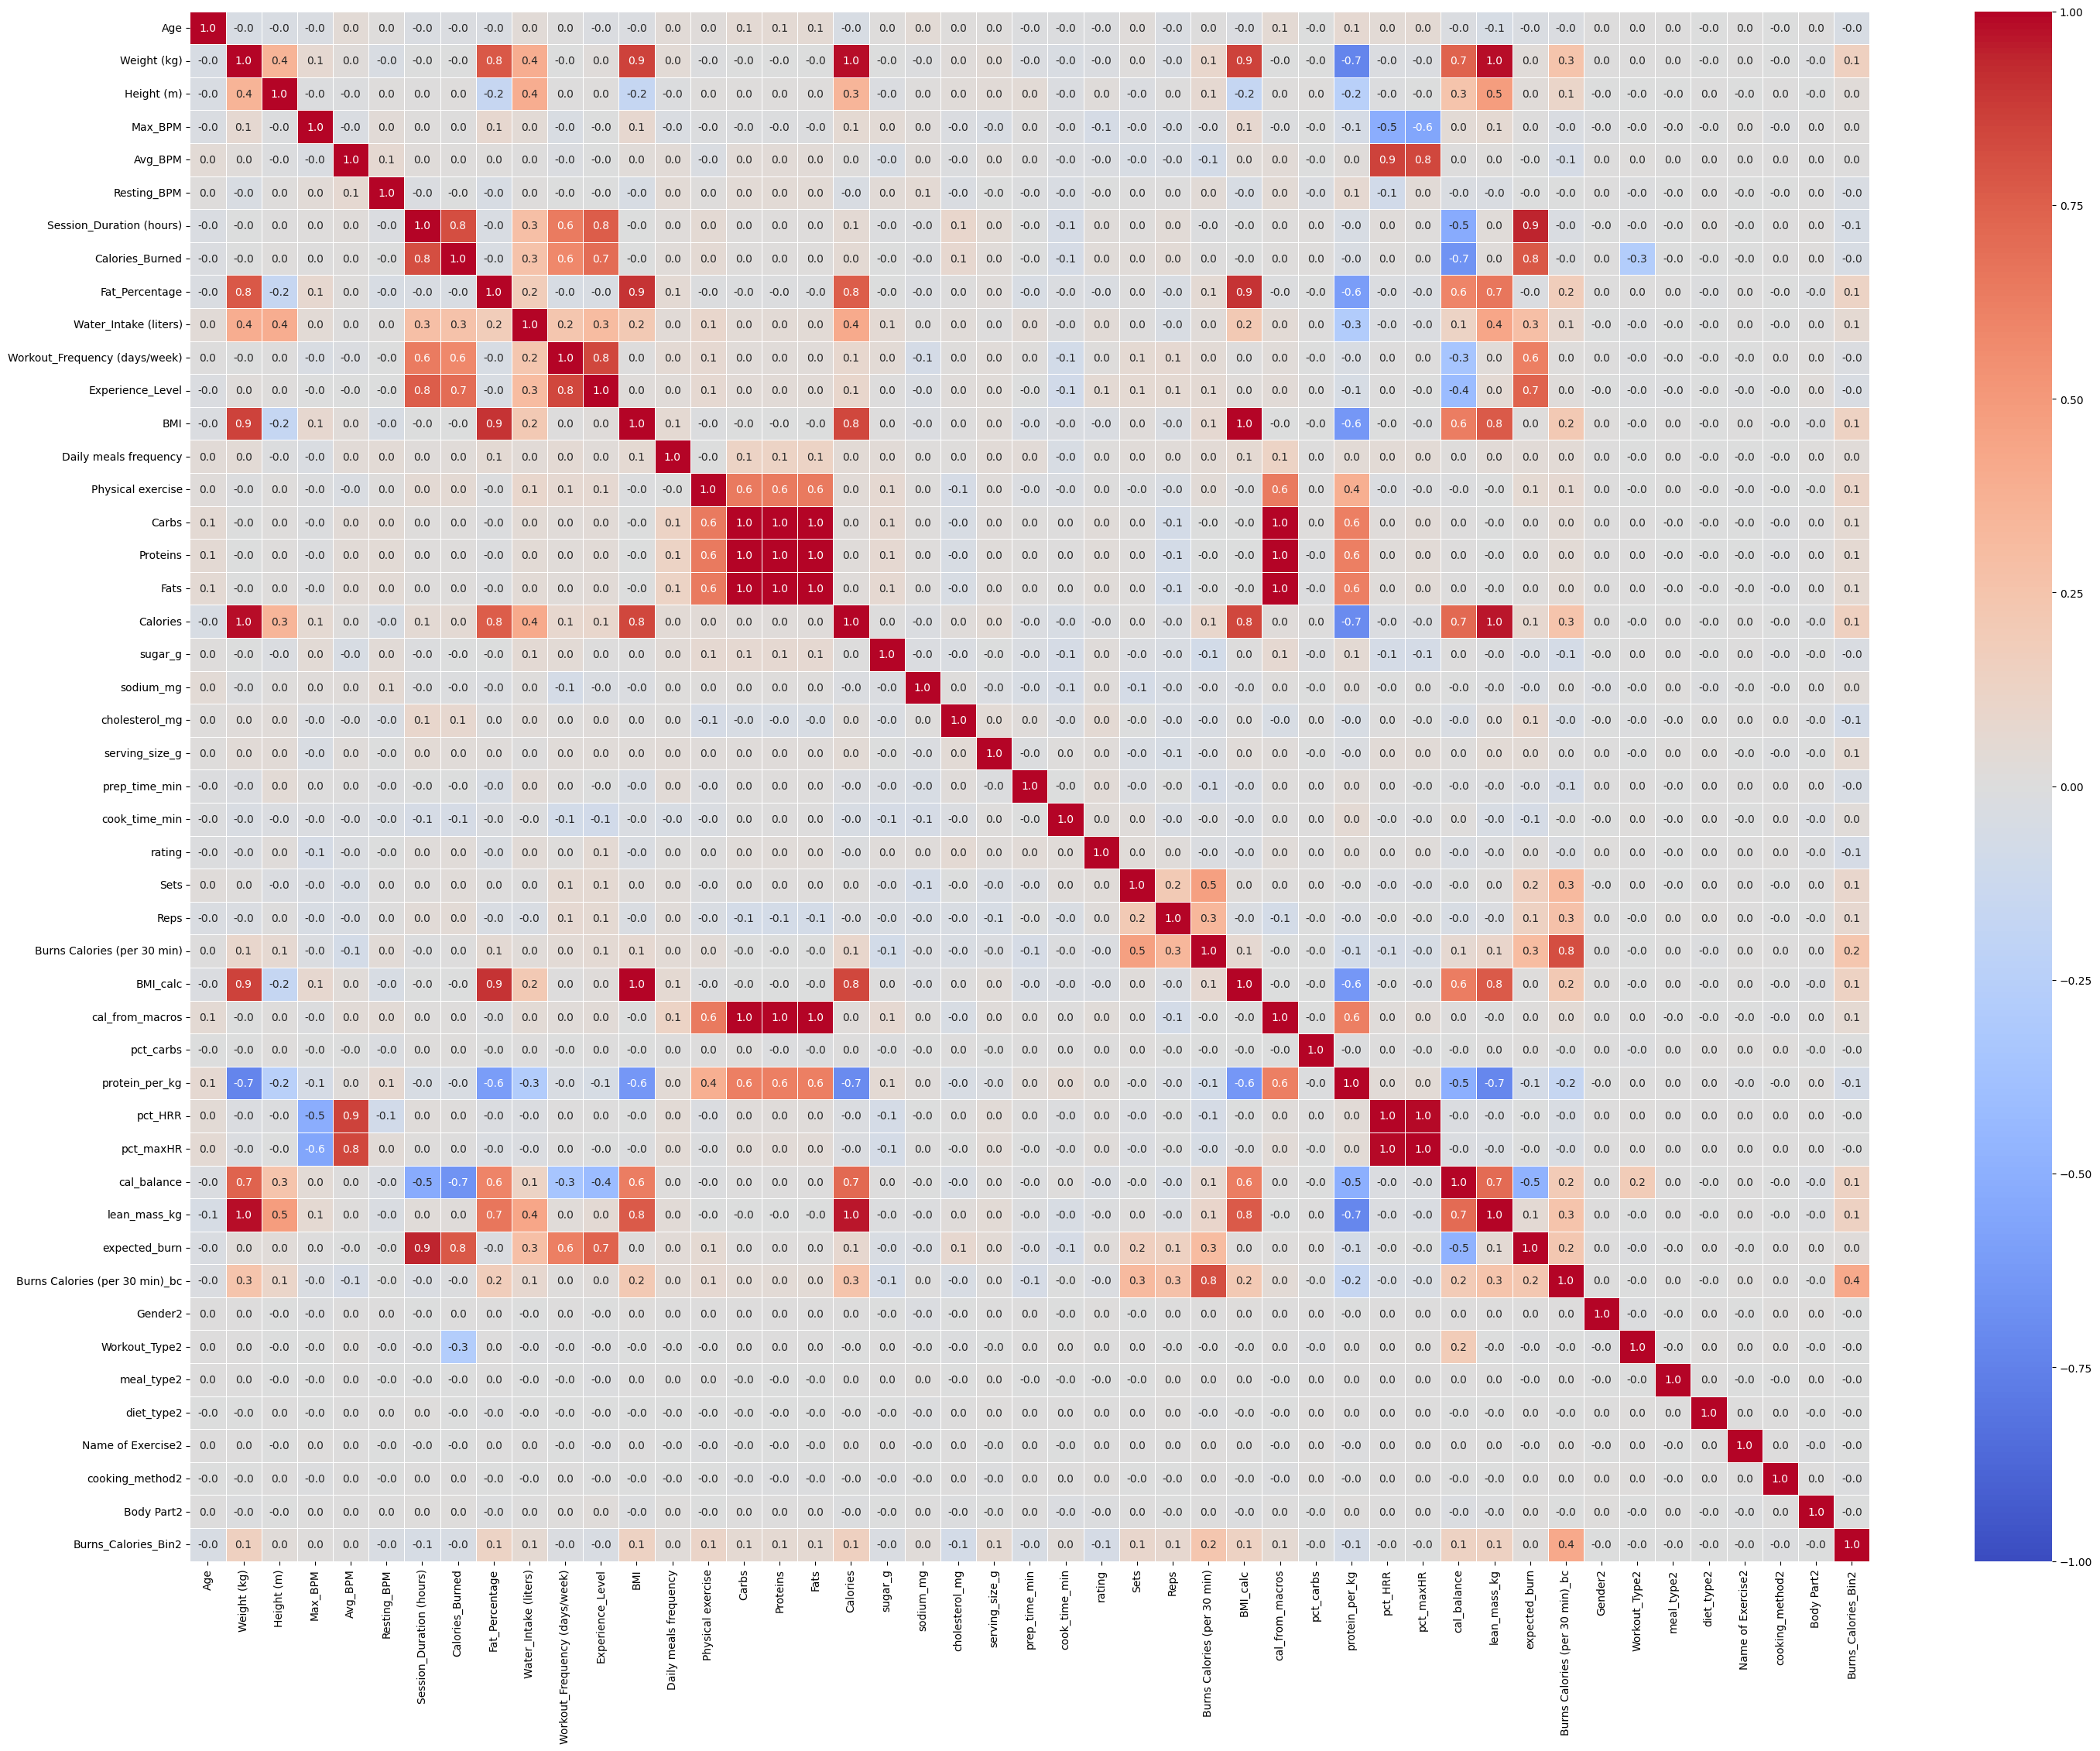

In [32]:
correlation_matrix = df_all.corr(numeric_only=True)

plt.figure(figsize=(35, 26))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5
)

In [34]:
pip install optuna


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 4.2 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.8 MB/s eta 0:00:00


In [37]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 62 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

In [42]:
integer_columns = df_all.select_dtypes(include=['int64']).columns.tolist()
float_columns = df_all.select_dtypes(include=['float64']).columns.tolist()
object_columns = df_all.select_dtypes(include=['object']).columns.tolist()

print('\nint64 columns:\n', integer_columns)
print('\nfloat64 columns:\n', float_columns)
print('\nobject columns:\n', object_columns)

num_columns = integer_columns + float_columns
print('\nall num columns:\n', num_columns)


int64 columns:
 ['Gender2', 'Workout_Type2', 'meal_type2', 'diet_type2', 'Name of Exercise2', 'cooking_method2', 'Body Part2', 'Burns_Calories_Bin2']

float64 columns:
 ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins', 'Fats', 'Calories', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'prep_time_min', 'cook_time_min', 'rating', 'Sets', 'Reps', 'Burns Calories (per 30 min)', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn', 'Burns Calories (per 30 min)_bc']

object columns:
 ['Gender', 'Workout_Type', 'meal_name', 'meal_type', 'diet_type', 'cooking_method', 'Name of Exercise', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Bod

In [43]:
df_numeric = df_all[num_columns]

In [44]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
import optuna
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import MinMaxScaler


scaler = StandardScaler()

scaled_features = df_numeric.copy()
scaled_features = scaler.fit_transform(scaled_features)
scaled_features_all = scaler.fit_transform(df_numeric)


def objective(trial):
    # Hiperparametry do optymalizacji optuna
    k = trial.suggest_int('n_clusters', 6, 8)
    init_method = trial.suggest_categorical('init', ['k-means++', 'random'])
    max_iter = trial.suggest_int('max_iter', 100, 1500, step=100)
    n_init = trial.suggest_int('n_init', 5, 40, step=5)
    batch_size = trial.suggest_int('batch_size', 500, 10000, step=500)

    kmeans = MiniBatchKMeans(
    n_clusters=k,
    init=init_method,
    max_iter=max_iter,
    n_init=n_init,
    random_state=42,
    batch_size=batch_size
    )

    """    kmeans = KMeans(
        n_clusters=4,  # CHce 4 bo sa 4 charaktery
        init=init_method,
        max_iter=max_iter,
        n_init=n_init,
        random_state=42
    )"""

    labels = kmeans.fit_predict(scaled_features)


    score =  calinski_harabasz_score(scaled_features, labels)
    return score  # Maksymalizujemy  score - calinski_harabasz_score -- stosunek między rozproszeniem międzyklastrowym a rozproszeniem wewnątrzklastrowym - performance

# Optymalizacja za pomocą Optuna
study = optuna.create_study(direction='maximize')  # Maksymalizujemy  score
study.optimize(objective, n_trials=20, n_jobs=-1)  # Liczba prób


print("Najlepsze parametry:", study.best_params)
print("Najlepszy Score:", study.best_value)

# Trening modelu z najlepszymi parametrami
best_params = study.best_params
final_kmeans = MiniBatchKMeans(
    n_clusters=best_params['n_clusters'],
    init=best_params['init'],
    max_iter=best_params['max_iter'],
    n_init=best_params['n_init'],
    batch_size=best_params['batch_size'],
    random_state=42

)

df_numeric['health_group'] = final_kmeans.fit_predict(scaled_features_all)


[I 2025-10-23 15:59:01,016] A new study created in memory with name: no-name-370be627-11f4-420f-8da0-a5b5991d6689
[I 2025-10-23 15:59:01,977] Trial 6 finished with value: 1166.1347247591484 and parameters: {'n_clusters': 7, 'init': 'random', 'max_iter': 300, 'n_init': 5, 'batch_size': 2500}. Best is trial 6 with value: 1166.1347247591484.
[I 2025-10-23 15:59:02,167] Trial 7 finished with value: 1042.6144038547034 and parameters: {'n_clusters': 7, 'init': 'random', 'max_iter': 1400, 'n_init': 25, 'batch_size': 6500}. Best is trial 6 with value: 1166.1347247591484.
[I 2025-10-23 15:59:02,203] Trial 5 finished with value: 978.2734964546528 and parameters: {'n_clusters': 8, 'init': 'random', 'max_iter': 900, 'n_init': 30, 'batch_size': 2000}. Best is trial 6 with value: 1166.1347247591484.
[I 2025-10-23 15:59:02,282] Trial 4 finished with value: 1207.7627675644235 and parameters: {'n_clusters': 6, 'init': 'random', 'max_iter': 200, 'n_init': 35, 'batch_size': 5000}. Best is trial 4 with va

Najlepsze parametry: {'n_clusters': 6, 'init': 'k-means++', 'max_iter': 700, 'n_init': 5, 'batch_size': 8000}
Najlepszy Score: 1241.898584626628


In [46]:
df_numeric.groupby('health_group').mean()

,Gender2,Workout_Type2,meal_type2,diet_type2,Name of Exercise2,cooking_method2,Body Part2,Burns_Calories_Bin2,Age,Weight (kg),...,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
health_group,,,,,,,,,,,,,,,,,,,,,
0,0.486670,1.499739,1.498693,2.478306,26.350758,2.992682,2.982227,1.729744,42.151976,68.422373,...,23.230432,2859.245687,0.499969,2.182247,0.688390,0.797226,611.709049,50.906840,878.430984,8.598218e+19
1,0.499568,1.449496,1.469640,2.541295,26.805180,2.988489,3.023885,1.393381,38.059942,75.552017,...,25.025756,1874.450757,0.500015,1.271880,0.677350,0.787245,177.172463,55.758572,1204.156414,8.568660e+19
2,0.499547,1.495014,1.502871,2.575703,26.943487,3.059837,3.015715,1.334542,40.229235,56.709166,...,19.276615,2048.180091,0.499952,1.848972,0.852909,0.906211,334.188879,44.065692,846.387824,7.882260e+19
3,0.496459,1.550223,1.463415,2.511146,26.744296,2.988461,2.971938,1.295043,37.175174,58.324487,...,20.167780,1902.925342,0.499969,1.679264,0.588670,0.730278,628.418419,44.842260,681.699374,7.660521e+19
4,0.500280,1.547286,1.534975,2.528260,26.849189,2.986570,2.945439,1.842473,37.880213,109.476122,...,34.638447,1968.923067,0.499952,0.911108,0.692796,0.796298,1800.610199,73.628648,788.434660,1.020151e+20
5,0.503320,1.511236,1.525792,2.441777,26.899898,3.008682,2.963228,1.508427,39.295884,72.326816,...,26.186115,1765.136581,0.500030,1.233612,0.706460,0.805965,807.693818,52.256423,828.468298,8.850707e+19
